### # Notebook para Análise de Doenças Cardíacas #

-----------------------------------------------------------------------------
### README: Objetivo e Passo a Passo da Análise
# -----------------------------------------------------------------------------
"""
**Objetivo:**
Este notebook tem como objetivo realizar uma análise exploratória e estatística do conjunto de dados de Doenças Cardíacas (UCI Heart Disease) para identificar associações entre variáveis categóricas (Tipo de Dor no Peito, Açúcar no Sangue em Jejum) e a presença de doença cardíaca.

**Passo a Passo:**
1.  **Configuração e Carregamento dos Dados:** Carregar o conjunto de dados a partir de uma URL, definir os nomes das colunas e tratar valores ausentes.
2.  **Limpeza e Preparação dos Dados:** Mapear variáveis categóricas para rótulos mais descritivos para facilitar a interpretação.
3.  **Análise Descritiva das Variáveis de Interesse:** Exibir a distribuição percentual das variáveis categóricas selecionadas.
4.  **Geração de Tabelas de Contingência e Teste de Qui-Quadrado:** Criar tabelas de contingência para examinar a relação entre pares de variáveis categóricas e realizar o teste de Qui-Quadrado para verificar a independência estatística.
5.  **Cálculo de Cramer's V:** Calcular a medida de associação Cramer's V para quantificar a força da associação entre as variáveis categóricas.
6.  **Conclusões:** Interpretar os resultados dos testes estatísticos (Qui-Quadrado e Cramer's V) e fornecer conclusões sobre a associação entre as variáveis.
"""


### Importando as bibliotecas

In [1]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np # Importa numpy para calcular Cramer's V

### Passo 1: Configuração e Carregamento dos Dados

In [2]:
# Define a URL para o conjunto de dados UCI Heart Disease
# Usaremos uma versão pré-processada e limpa para este exemplo
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Define os nomes das colunas, pois o arquivo não tem cabeçalho
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]


# Carrega os dados em um DataFrame do pandas
df = pd.read_csv(url, names=columns, na_values='?')
print("Dados carregados com sucesso.")

Dados carregados com sucesso.


In [5]:
print(df.shape)
print(df.info())

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [8]:
df.tail(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


Passo2: # Limpeza e preparação dos dados

In [9]:
# As variáveis cp, fbs, e target já são numéricas, mas vamos mapear
# para que a análise descritiva seja mais clara.
print("\nPreparando os dados para análise...")


# A coluna 'target' tem valores 0 e 1, onde 1 significa doença cardíaca presente.
# Vamos mapeá-la para ser mais descritiva.
df['target'] = df['target'].map({0: 'Ausência de Doença', 1: 'Presença de Doença'})

# Mapeia a variável 'cp' (tipo de dor no peito)
cp_mapping = {
    1: 'Angina Típica',
    2: 'Angina Atípica',
    3: 'Dor Não-Angina',
    4: 'Assintomático'
}
df['cp'] = df['cp'].map(cp_mapping)

# Mapeia a variável 'fbs' (açúcar no sangue em jejum)
fbs_mapping = {0: '<= 120 mg/dL', 1: '> 120 mg/dL'}
df['fbs'] = df['fbs'].map(fbs_mapping)

print("Variáveis categóricas mapeadas para rótulos mais descritivos.")


Preparando os dados para análise...
Variáveis categóricas mapeadas para rótulos mais descritivos.


### Passo 3: Análise Descritiva das Variáveis de Interesse

In [10]:
print("\n--- Análise Descritiva das Variáveis ---")

# Análise da variável 'fbs'
print("\n2. Distribuição da variável 'fbs' (Açúcar no Sangue em Jejum > 120 mg/dL):")
print(df['fbs'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Análise da variável 'cp'
print("\n3. Distribuição da variável 'cp' (Tipo de Dor no Peito):")
print(df['cp'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Análise da variável 'target'
print("\n4. Distribuição da variável 'target' (Presença de Doença Cardíaca):")
print(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


--- Análise Descritiva das Variáveis ---

2. Distribuição da variável 'fbs' (Açúcar no Sangue em Jejum > 120 mg/dL):
fbs
<= 120 mg/dL    85.15%
> 120 mg/dL     14.85%
Name: proportion, dtype: object

3. Distribuição da variável 'cp' (Tipo de Dor no Peito):
cp
Assintomático     47.52%
Dor Não-Angina    28.38%
Angina Atípica     16.5%
Angina Típica      7.59%
Name: proportion, dtype: object

4. Distribuição da variável 'target' (Presença de Doença Cardíaca):
target
Ausência de Doença    74.89%
Presença de Doença    25.11%
Name: proportion, dtype: object


/tmp/ipython-input-1889820115.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='fbs', data=df, palette=[colors[1]])
/tmp/ipython-input-1889820115.py:15: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(ax=axes[0], x='fbs', data=df, palette=[colors[1]])
/tmp/ipython-input-1889820115.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], x='cp', data=df, palette=colors)
/tmp/ipython-input-1889820115.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for

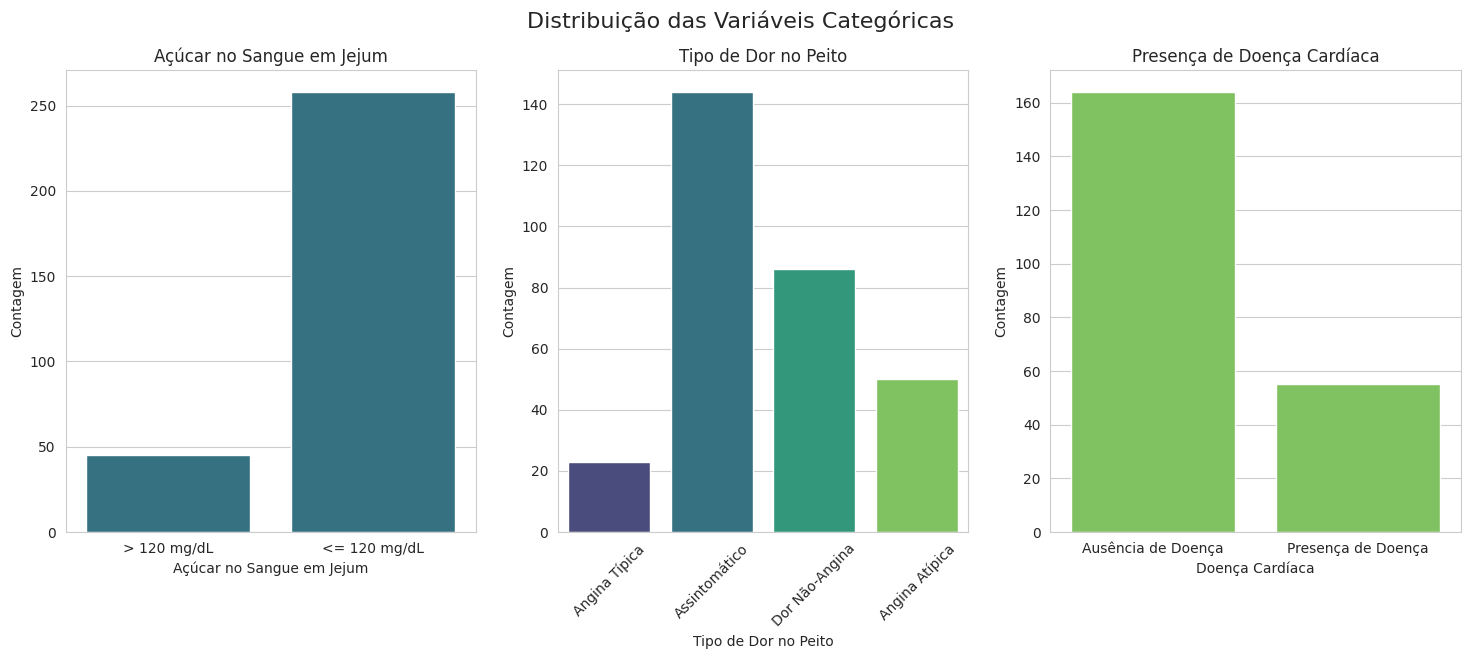

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a paleta de cores
colors = sns.color_palette('viridis', 4)

# Configura o estilo dos gráficos
sns.set_style('whitegrid')

# Cria os subplots para 3 gráficos em uma linha
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Alterado para 1 linha e 3 colunas
fig.suptitle('Distribuição das Variáveis Categóricas', fontsize=16)

# Gráfico para 'fbs' (agora no primeiro subplot)
sns.countplot(ax=axes[0], x='fbs', data=df, palette=[colors[1]])
axes[0].set_title('Açúcar no Sangue em Jejum')
axes[0].set_xlabel('Açúcar no Sangue em Jejum')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico para 'cp' (agora no segundo subplot)
sns.countplot(ax=axes[1], x='cp', data=df, palette=colors)
axes[1].set_title('Tipo de Dor no Peito')
axes[1].set_xlabel('Tipo de Dor no Peito')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=45)

# Gráfico para 'target' (agora no terceiro subplot)
sns.countplot(ax=axes[2], x='target', data=df, palette=[colors[3]])
axes[2].set_title('Presença de Doença Cardíaca')
axes[2].set_xlabel('Doença Cardíaca')
axes[2].set_ylabel('Contagem')
axes[2].tick_params(axis='x', rotation=0)


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição
plt.show()

In [14]:
# Verificar se há valores ausentes na coluna 'target'
print("Contagem de valores ausentes na coluna 'target':")
print(df['target'].isnull().sum())

# Verificar a distribuição dos valores na coluna 'target', incluindo NaNs se houver
print("\nDistribuição dos valores na coluna 'target' (incluindo NaNs):")
print(df['target'].value_counts(dropna=False))

Contagem de valores ausentes na coluna 'target':
84

Distribuição dos valores na coluna 'target' (incluindo NaNs):
target
Ausência de Doença    164
NaN                    84
Presença de Doença     55
Name: count, dtype: int64


### Passo 3: Geração de Tabelas de Contingência e Teste de Qui-Quadrado e Cramer's V

In [16]:
# Cria a tabela de contingência para 'cp' e 'target' usando pd.crosstab com margens
contingency_table_cp_target = pd.crosstab(df['cp'], df['target'], margins=True)

# Imprime a tabela de contingência
print("Tabela de Contingência (cp e target) com Totais Marginais:")
print(contingency_table_cp_target)

Tabela de Contingência (cp e target) com Totais Marginais:
target          Ausência de Doença  Presença de Doença  All
cp                                                         
Angina Atípica                  41                   6   47
Angina Típica                   16                   5   21
Assintomático                   39                  35   74
Dor Não-Angina                  68                   9   77
All                            164                  55  219


### Cria uma função para teste qui-quadrado: Testar a existência de associação

In [33]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

def perform_chi2_test(df, var1, var2='target'):
    """
    Cria uma tabela de contingência entre a variável especificada e a variável target,
    realiza o teste de Qui-Quadrado e imprime os resultados.

    Args:
        df (pd.DataFrame): O DataFrame contendo os dados.
        var1 (str): O nome da primeira variável categórica.
        var2 (str): O nome da segunda variável categórica (padrão: 'target').

    Returns:
        tuple: Uma tupla contendo (estatística qui-quadrado, valor-p, graus de liberdade, frequências esperadas).
    """
    print(f"\n--- Análise de Associação (Qui-Quadrado) entre {var1} e {var2} ---")

    # Cria a tabela de contingência (excluindo os totais marginais para o teste)
    contingency_table = pd.crosstab(df[var1], df[var2], margins=False)
    print("\nTabela de Contingência:")
    print(contingency_table)

    # Adiciona médias das linhas e colunas (opcional)
    # print("\nMédias por Linha:")
    # print(contingency_table.mean(axis=1))
    # print("\nMédias por Coluna:")
    # print(contingency_table.mean(axis=0))

    # Realiza o teste de Qui-Quadrado
    stat, p, dof, expected = chi2_contingency(contingency_table)

    print("\nResultados do Teste de Qui-Quadrado:")
    print(f"Estatística Qui-Quadrado (X²): {stat:.4f}")
    print(f"Valor-p (p-value): {p:.4f}")
    print(f"Graus de Liberdade (dof): {dof}")
    print("\nTabela de Frequências Esperadas:")
    print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

    # Conclusão baseada no valor-p
    alpha = 0.05
    print("\nConclusão do Teste de Qui-Quadrado:")
    if p < alpha:
        print(f"Existe uma associação estatisticamente significativa entre {var1} e {var2} (p = {p:.4f}).")
        print("Rejeitamos a hipótese nula de independência.")
    else:
        print(f"Não há evidência de associação estatisticamente significativa entre {var1} e {var2} (p = {p:.4f}).")
        print("Não rejeitamos a hipótese nula de independência.")

    return stat, p, dof, expected

### Chama a função para testar a associação entre tipo de dor e target

In [34]:
perform_chi2_test(df, 'cp','target')


--- Análise de Associação (Qui-Quadrado) entre cp e target ---

Tabela de Contingência:
target          Ausência de Doença  Presença de Doença
cp                                                    
Angina Atípica                  41                   6
Angina Típica                   16                   5
Assintomático                   39                  35
Dor Não-Angina                  68                   9

Resultados do Teste de Qui-Quadrado:
Estatística Qui-Quadrado (X²): 30.5719
Valor-p (p-value): 0.0000
Graus de Liberdade (dof): 3

Tabela de Frequências Esperadas:
target          Ausência de Doença  Presença de Doença
cp                                                    
Angina Atípica           35.196347           11.803653
Angina Típica            15.726027            5.273973
Assintomático            55.415525           18.584475
Dor Não-Angina           57.662100           19.337900

Conclusão do Teste de Qui-Quadrado:
Existe uma associação estatisticamente significat

(np.float64(30.57194907802423),
 np.float64(1.0460527383618916e-06),
 3,
 array([[35.19634703, 11.80365297],
        [15.7260274 ,  5.2739726 ],
        [55.41552511, 18.58447489],
        [57.66210046, 19.33789954]]))

## Avalia o grau de associação - Cramers V

In [38]:
# Crie a tabela de contingência para 'cp' e 'target' (sem margens para o teste)
contingency_table_cp_target = pd.crosstab(df['cp'], df['target'], margins=False)

# Obtenha as informações necessárias para Cramer's V
n_observations = contingency_table_cp_target.sum().sum()
num_rows, num_cols = contingency_table_cp_target.shape

# Realize o teste de Qui-Quadrado para obter a estatística 'stat'
stat, p_value, degrees_freedom, expected_freq = chi2_contingency(contingency_table_cp_target)

# Calcule Cramer's V usando a estatística do Qui-Quadrado e as dimensões da tabela
cramers_v_value = calculate_cramers_v(stat, n_observations, num_rows, num_cols)

# Opcional: Imprimir o valor de Cramer's V (já é impresso dentro da função, mas pode ser útil ter o valor retornado)
# print(f"\nValor de Cramer's V calculado: {cramers_v_value:.4f}")


--- Resultado e Conclusão de Cramer's V ---
Cramer's V: 0.3736

Força da Associação (Cramer's V):
A força da associação é moderada.


### Chama a função para testar a associação entre nível de açúcar no sangue e target

In [39]:
perform_chi2_test(df, 'fbs','target')


--- Análise de Associação (Qui-Quadrado) entre fbs e target ---

Tabela de Contingência:
target        Ausência de Doença  Presença de Doença
fbs                                                 
<= 120 mg/dL                 141                  51
> 120 mg/dL                   23                   4

Resultados do Teste de Qui-Quadrado:
Estatística Qui-Quadrado (X²): 1.1685
Valor-p (p-value): 0.2797
Graus de Liberdade (dof): 1

Tabela de Frequências Esperadas:
target        Ausência de Doença  Presença de Doença
fbs                                                 
<= 120 mg/dL          143.780822           48.219178
> 120 mg/dL            20.219178            6.780822

Conclusão do Teste de Qui-Quadrado:
Não há evidência de associação estatisticamente significativa entre fbs e target (p = 0.2797).
Não rejeitamos a hipótese nula de independência.


(np.float64(1.1685399632760531),
 np.float64(0.27970144192910606),
 1,
 array([[143.78082192,  48.21917808],
        [ 20.21917808,   6.78082192]]))

#### FIM DA ANÁLISE